In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

In [2]:
X_train = np.load("../processed/X_train.npy")
X_test = np.load("../processed/X_test.npy")

y_train = np.load("../processed/y_train.npy")
y_test = np.load("../processed/y_test.npy")

print(X_train.shape)

(11881, 20)


In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("RF Accuracy:", rf_acc)

RF Accuracy: 0.7263547627061595


In [4]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("XGB Accuracy:", xgb_acc)

XGB Accuracy: 0.7209693705822955


In [5]:
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)

print(X_train_lstm.shape)

(11881, 1, 20)


In [6]:
num_classes = len(np.unique(y_train))

model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    BatchNormalization(),

    Dropout(0.2),

    LSTM(
        64
    ),

    Dropout(0.2),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        num_classes,
        activation="softmax"
    )
])

optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,547 (517.76 KB)

 Trainable params: 132,291 (516.76 KB)

 Non-trainable params: 256 (1.00 KB)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [8]:
history = model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6595 - loss: 0.6879 - val_accuracy: 0.5789 - val_loss: 0.7687 - learning_rate: 0.0010
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6912 - loss: 0.6267 - val_accuracy: 0.6988 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6948 - loss: 0.6214 - val_accuracy: 0.6929 - val_loss: 0.6077 - learning_rate: 0.0010
Epoch 4/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7017 - loss: 0.6076 - val_accuracy: 0.7076 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 5/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7049 - loss: 0.6051 - val_accuracy: 0.6845 - val_loss: 0.6161 - learning_rate: 0.0010
Epoch 6/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7003 - loss: 0.5993 - val_accuracy: 0.7093 - val_loss: 0.5752 - learning_rate: 0.0010
Epoch 7/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7108 - loss: 0.5929 - 

In [9]:
loss, lstm_acc = model.evaluate(
    X_test_lstm,
    y_test,
    verbose=0
)

print("LSTM Accuracy:", lstm_acc)

LSTM Accuracy: 0.7263547778129578


In [10]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],
    "Accuracy": [
        rf_acc,
        xgb_acc,
        lstm_acc
    ]
})

print(results)

           Model  Accuracy
0  Random Forest  0.726355
1        XGBoost  0.720969
2           LSTM  0.726355


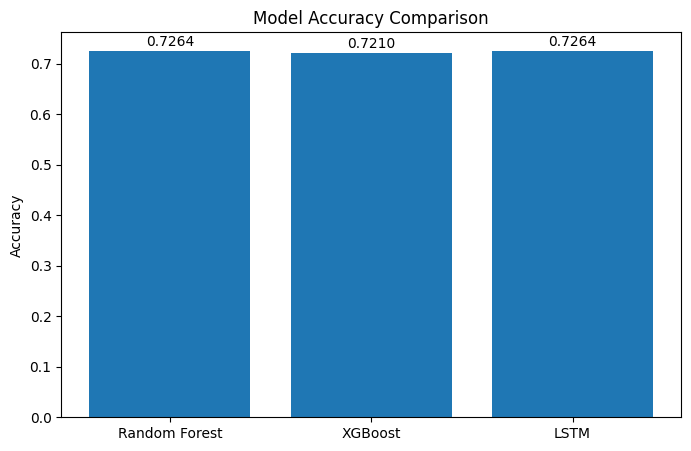

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for i, acc in enumerate(results["Accuracy"]):
    plt.text(
        i,
        acc + 0.01,
        f"{acc:.4f}",
        ha="center"
    )

plt.show()

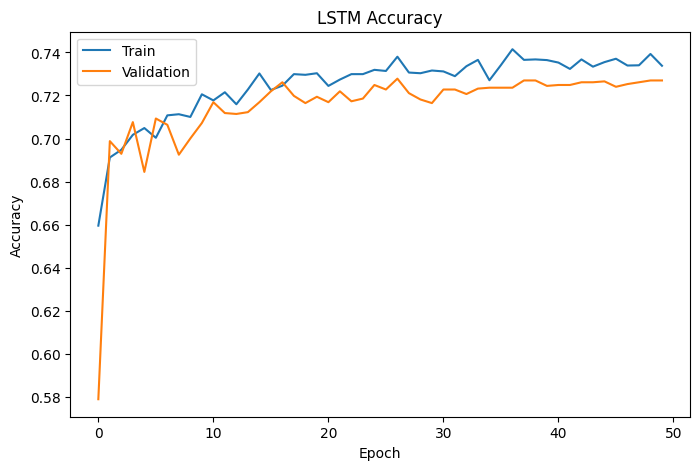

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

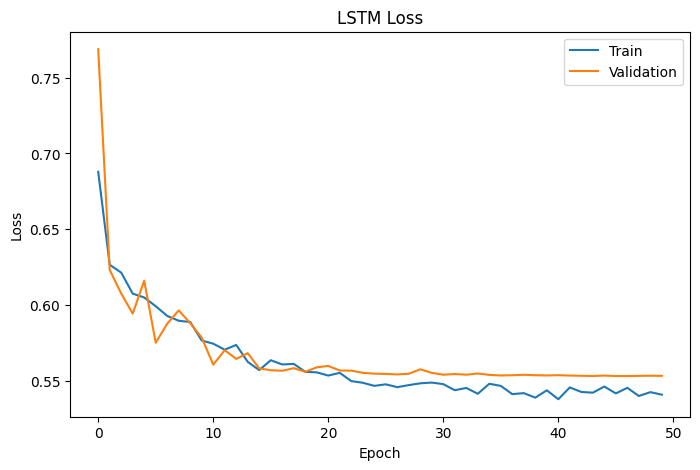

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


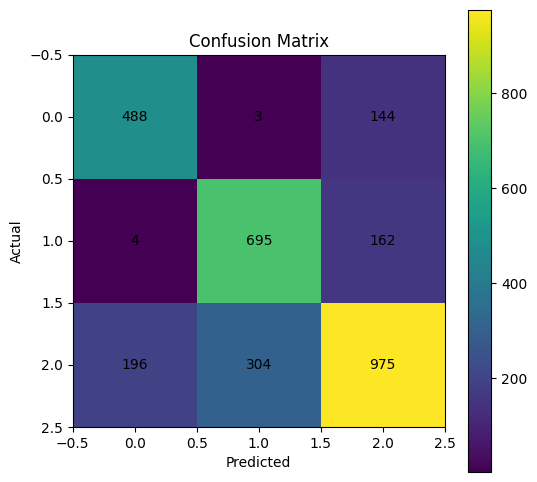

In [14]:
pred = model.predict(X_test_lstm)

pred = np.argmax(pred, axis=1)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.show()

In [15]:
model.save(
    "../models/smartgrid_lstm_model.h5"
)

print("Model Saved")

Model Saved
